In [ ]:
import glob

files = sorted(glob.glob('../data/20260820T154500/solo_L2_eui-hrieuv174-image_*.fits'))
print(len(files))
print(files)

45
['../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T154556280_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T154656280_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T154756280_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T154856280_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T154956280_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T155056280_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T155156281_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T155256281_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T155356281_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T155456735_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T155556281_V00.fits', '../data/20260820T154500\\solo_L2_eui-hrieuv174-image_20260820T155656282

There are two different sets of files: hundreds of "-short" files, roughly every 2 seconds (high-resolution, high-cadence images), and 45 "regular" files, roughly every 100 seconds.

Since the flare (per the GOES/STIX work) has its main peaks around 15:55 and 16:00, select:

In [5]:
import sunpy
import sunpy.map
import pandas as pd
import numpy as np

maps = [sunpy.map.Map(f) for f in files]

target_times = pd.to_datetime([
    "2026-08-20 15:50:00",
    "2026-08-20 15:56:00",
    "2026-08-20 16:00:00",
    "2026-08-20 16:05:00",
    "2026-08-20 16:15:00",
    "2026-08-20 16:20:00",
    "2026-08-20 16:30:00",
    "2026-08-20 16:50:00",
])

map_times = pd.to_datetime([m.date.iso for m in maps])

selected_maps = []
for target in target_times:
    closest_idx = np.abs(map_times - target).argmin()
    selected_maps.append(maps[closest_idx])
    print(f"Target: {target}, Found: {map_times[closest_idx]}")

#this picks the actual frame closest to each target time, so that i dont have to manually match timestamps to list positions.



Target: 2026-08-20 15:50:00, Found: 2026-08-20 15:49:56.280000
Target: 2026-08-20 15:56:00, Found: 2026-08-20 15:55:56.281000
Target: 2026-08-20 16:00:00, Found: 2026-08-20 15:59:56.579000
Target: 2026-08-20 16:05:00, Found: 2026-08-20 16:04:56.511000
Target: 2026-08-20 16:15:00, Found: 2026-08-20 16:14:56.482000
Target: 2026-08-20 16:20:00, Found: 2026-08-20 16:19:56.284000
Target: 2026-08-20 16:30:00, Found: 2026-08-20 16:29:56.285000
Target: 2026-08-20 16:50:00, Found: 2026-08-20 16:29:56.285000


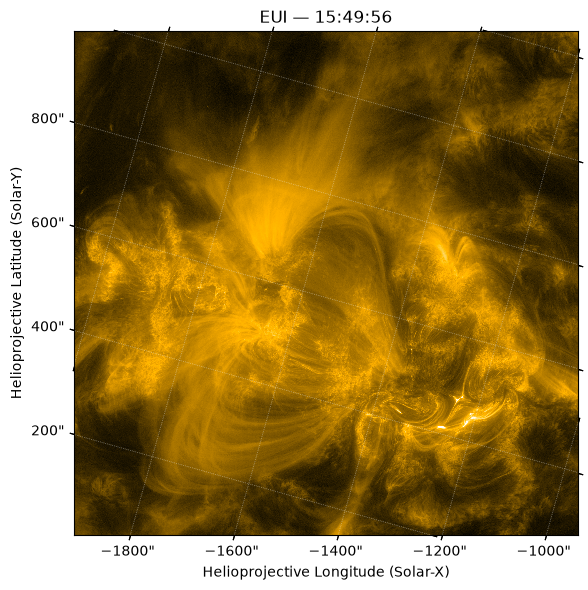

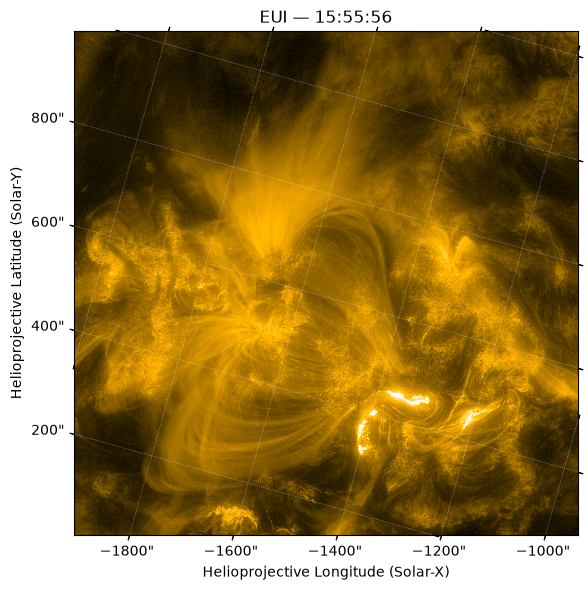

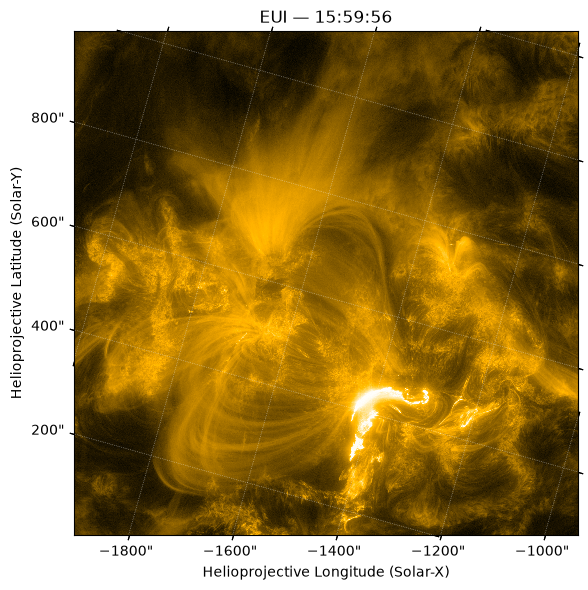

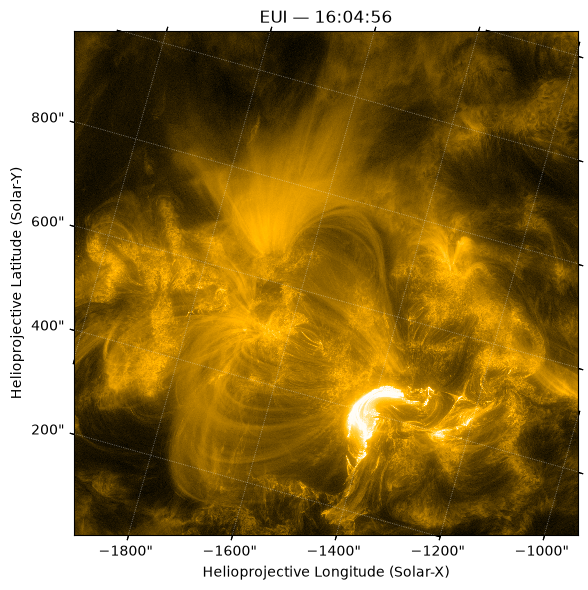

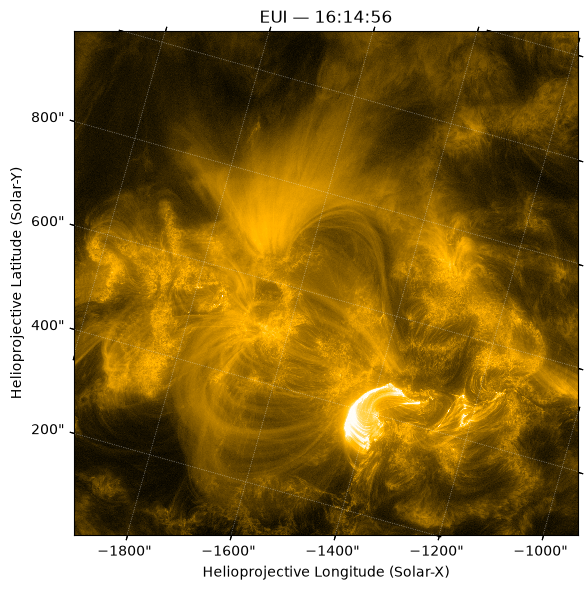

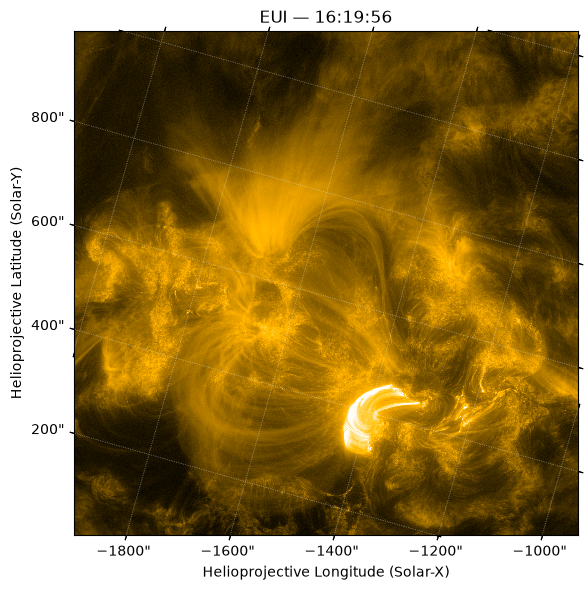

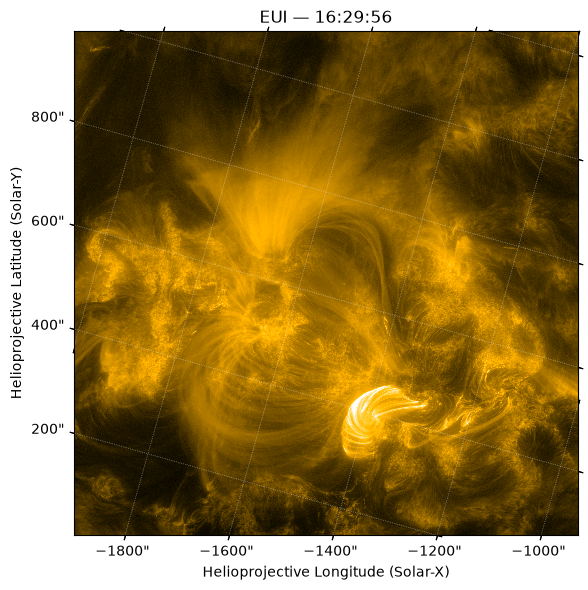

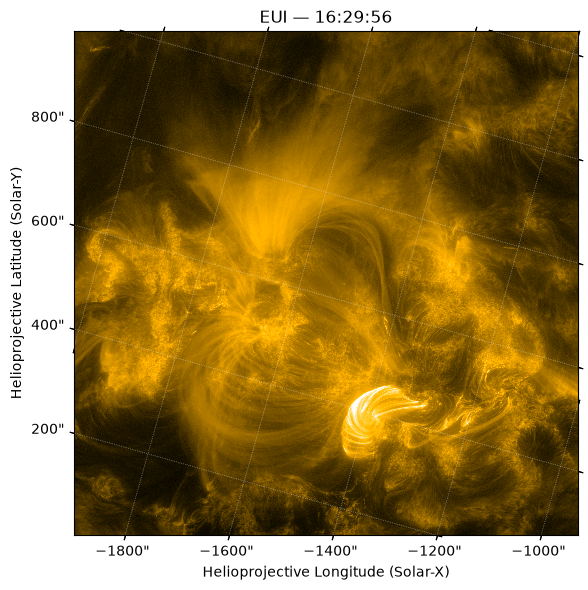

In [ ]:
import matplotlib.pyplot as plt

for m in selected_maps:

    fig = plt.figure(figsize=(6, 6))

    ax = fig.add_subplot(
        1, 1, 1,
        projection=m.wcs
    )

    m.plot(axes=ax)

    ax.set_title(f"EUI — {m.date.iso[11:19]}")

    plt.tight_layout()

    #save each image separately
    timestamp = m.date.iso[11:19].replace(":", "")
    plt.savefig(
        f"../figures/eui_{timestamp}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

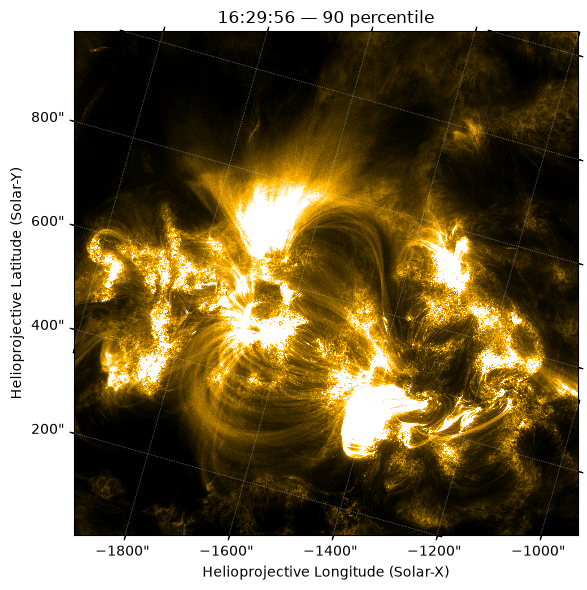

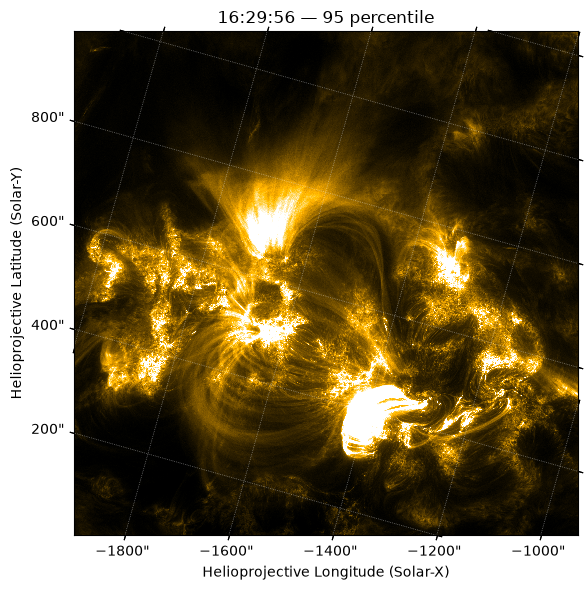

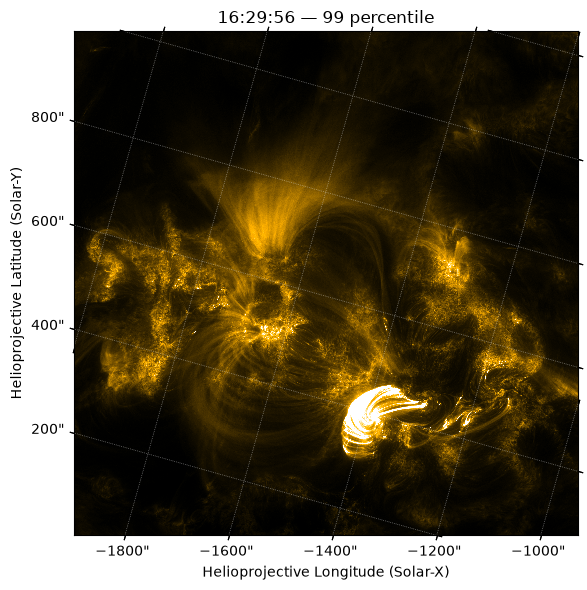

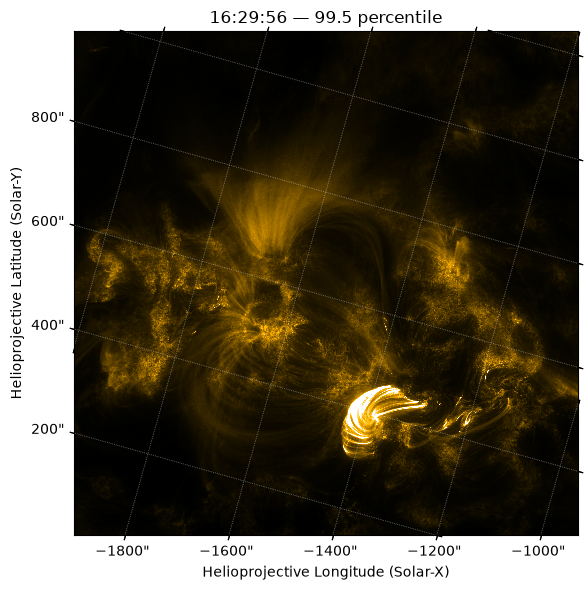

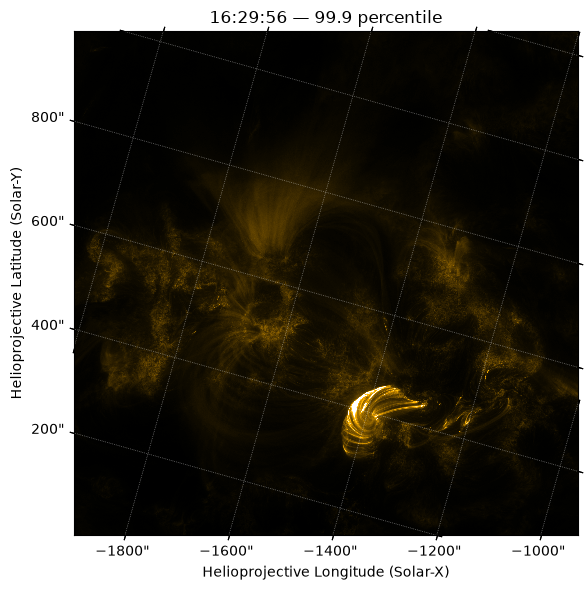

In [ ]:
#experiment with display scaling
import sunpy
import sunpy.map
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt


from astropy.visualization import ImageNormalize
from astropy.visualization import LogStretch
from astropy.visualization import LinearStretch
from astropy.visualization import PercentileInterval



files = sorted(glob.glob('../data/20260820T154500/solo_L2_eui-hrieuv174-image_*.fits'))

maps = [sunpy.map.Map(f) for f in files]

target_times = pd.to_datetime([
    "2026-08-20 15:50:00",
    "2026-08-20 15:56:00",
    "2026-08-20 16:00:00",
    "2026-08-20 16:05:00",
    "2026-08-20 16:15:00",
    "2026-08-20 16:20:00",
    "2026-08-20 16:30:00",
    "2026-08-20 16:50:00",
])

map_times = pd.to_datetime([m.date.iso for m in maps])

selected_maps = []
for target in target_times:
    closest_idx = np.abs(map_times - target).argmin()
    selected_maps.append(maps[closest_idx])

percentiles = [90, 95, 99, 99.5, 99.9]

for percentile in percentiles:

    fig = plt.figure(figsize=(6, 6))

    ax = fig.add_subplot(
        1, 1, 1,
        projection=m.wcs
    )

    norm = ImageNormalize(
        m.data,
        interval=PercentileInterval(percentile),
        stretch=LinearStretch()  #display intensity linearly
    )

    m.plot(
        axes=ax,
        norm=norm
    )

    ax.set_title(
        f"{m.date.iso[11:19]} — {percentile} percentile"
    )

    # Save each image separately
    timestamp = m.date.iso[11:19].replace(":", "")
    plt.savefig(
        f"../figures/eui_{percentile}_{timestamp}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.tight_layout()
    plt.show()
    plt.close(fig)

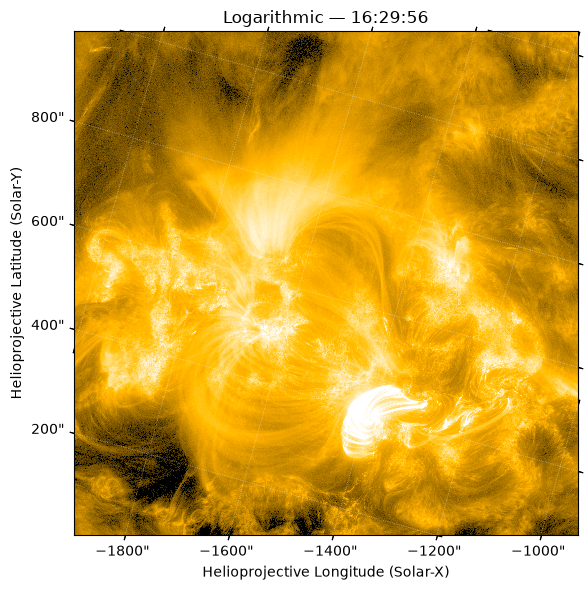

In [ ]:
m = selected_maps[7]

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(
    1, 1, 1,
    projection=m.wcs
)

norm = ImageNormalize(
    m.data,
    interval=PercentileInterval(99),
    stretch=LogStretch() #display intensity logarithmically
)

m.plot(
    axes=ax,
    norm=norm
)

ax.set_title(f"Logarithmic — {m.date.iso[11:19]}")

plt.savefig(
        f"../figures/eui_logstretch.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.tight_layout()
plt.show()


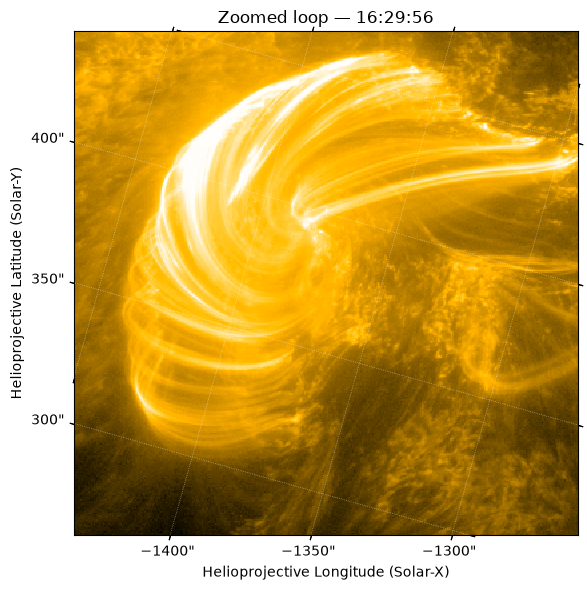

In [31]:
import astropy.units as u
from astropy.coordinates import SkyCoord

# pick which frame to zoom into - e.g. your most developed arcade frame
m = selected_maps[7]  # adjust index to whichever frame shows the loop best

# define a box around the loop, centered on lon=-1400", lat=400"
zoom_width = 150 * u.arcsec
zoom_height = 150 * u.arcsec

bottom_left = SkyCoord(-1370*u.arcsec - zoom_width/2, 375*u.arcsec - zoom_height/2,
                        frame=m.coordinate_frame)
top_right = SkyCoord(-1370*u.arcsec + zoom_width/2, 375*u.arcsec + zoom_height/2,
                      frame=m.coordinate_frame)

zoomed_map = m.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map.wcs
)
zoomed_map.plot(axes=ax)
ax.set_title(f'Zoomed loop — {m.date.iso[11:19]}')
plt.tight_layout()
plt.savefig('../figures/eui_loop_zoom.png')
plt.show()